<a href="https://colab.research.google.com/github/notJishnu/Jishnu_Guha/blob/main/real_estate2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from joblib import dump, load

In [3]:
housing = pd.read_csv("BostonHousing.csv")

print(f"Shape: {housing.shape}")
print(f"\nColumns: {list(housing.columns)}")
housing.head()

Shape: (506, 14)

Columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
# Summary statistics and missing value check
print("=== Dataset Info ===")
housing.info()

print("\n=== Missing Values ===")
print(housing.isnull().sum()[housing.isnull().sum() > 0])

print("\n=== Descriptive Statistics ===")
housing.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

=== Missing Values ===
Series([], dtype: int64)

=== Descriptive Statistics ===


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


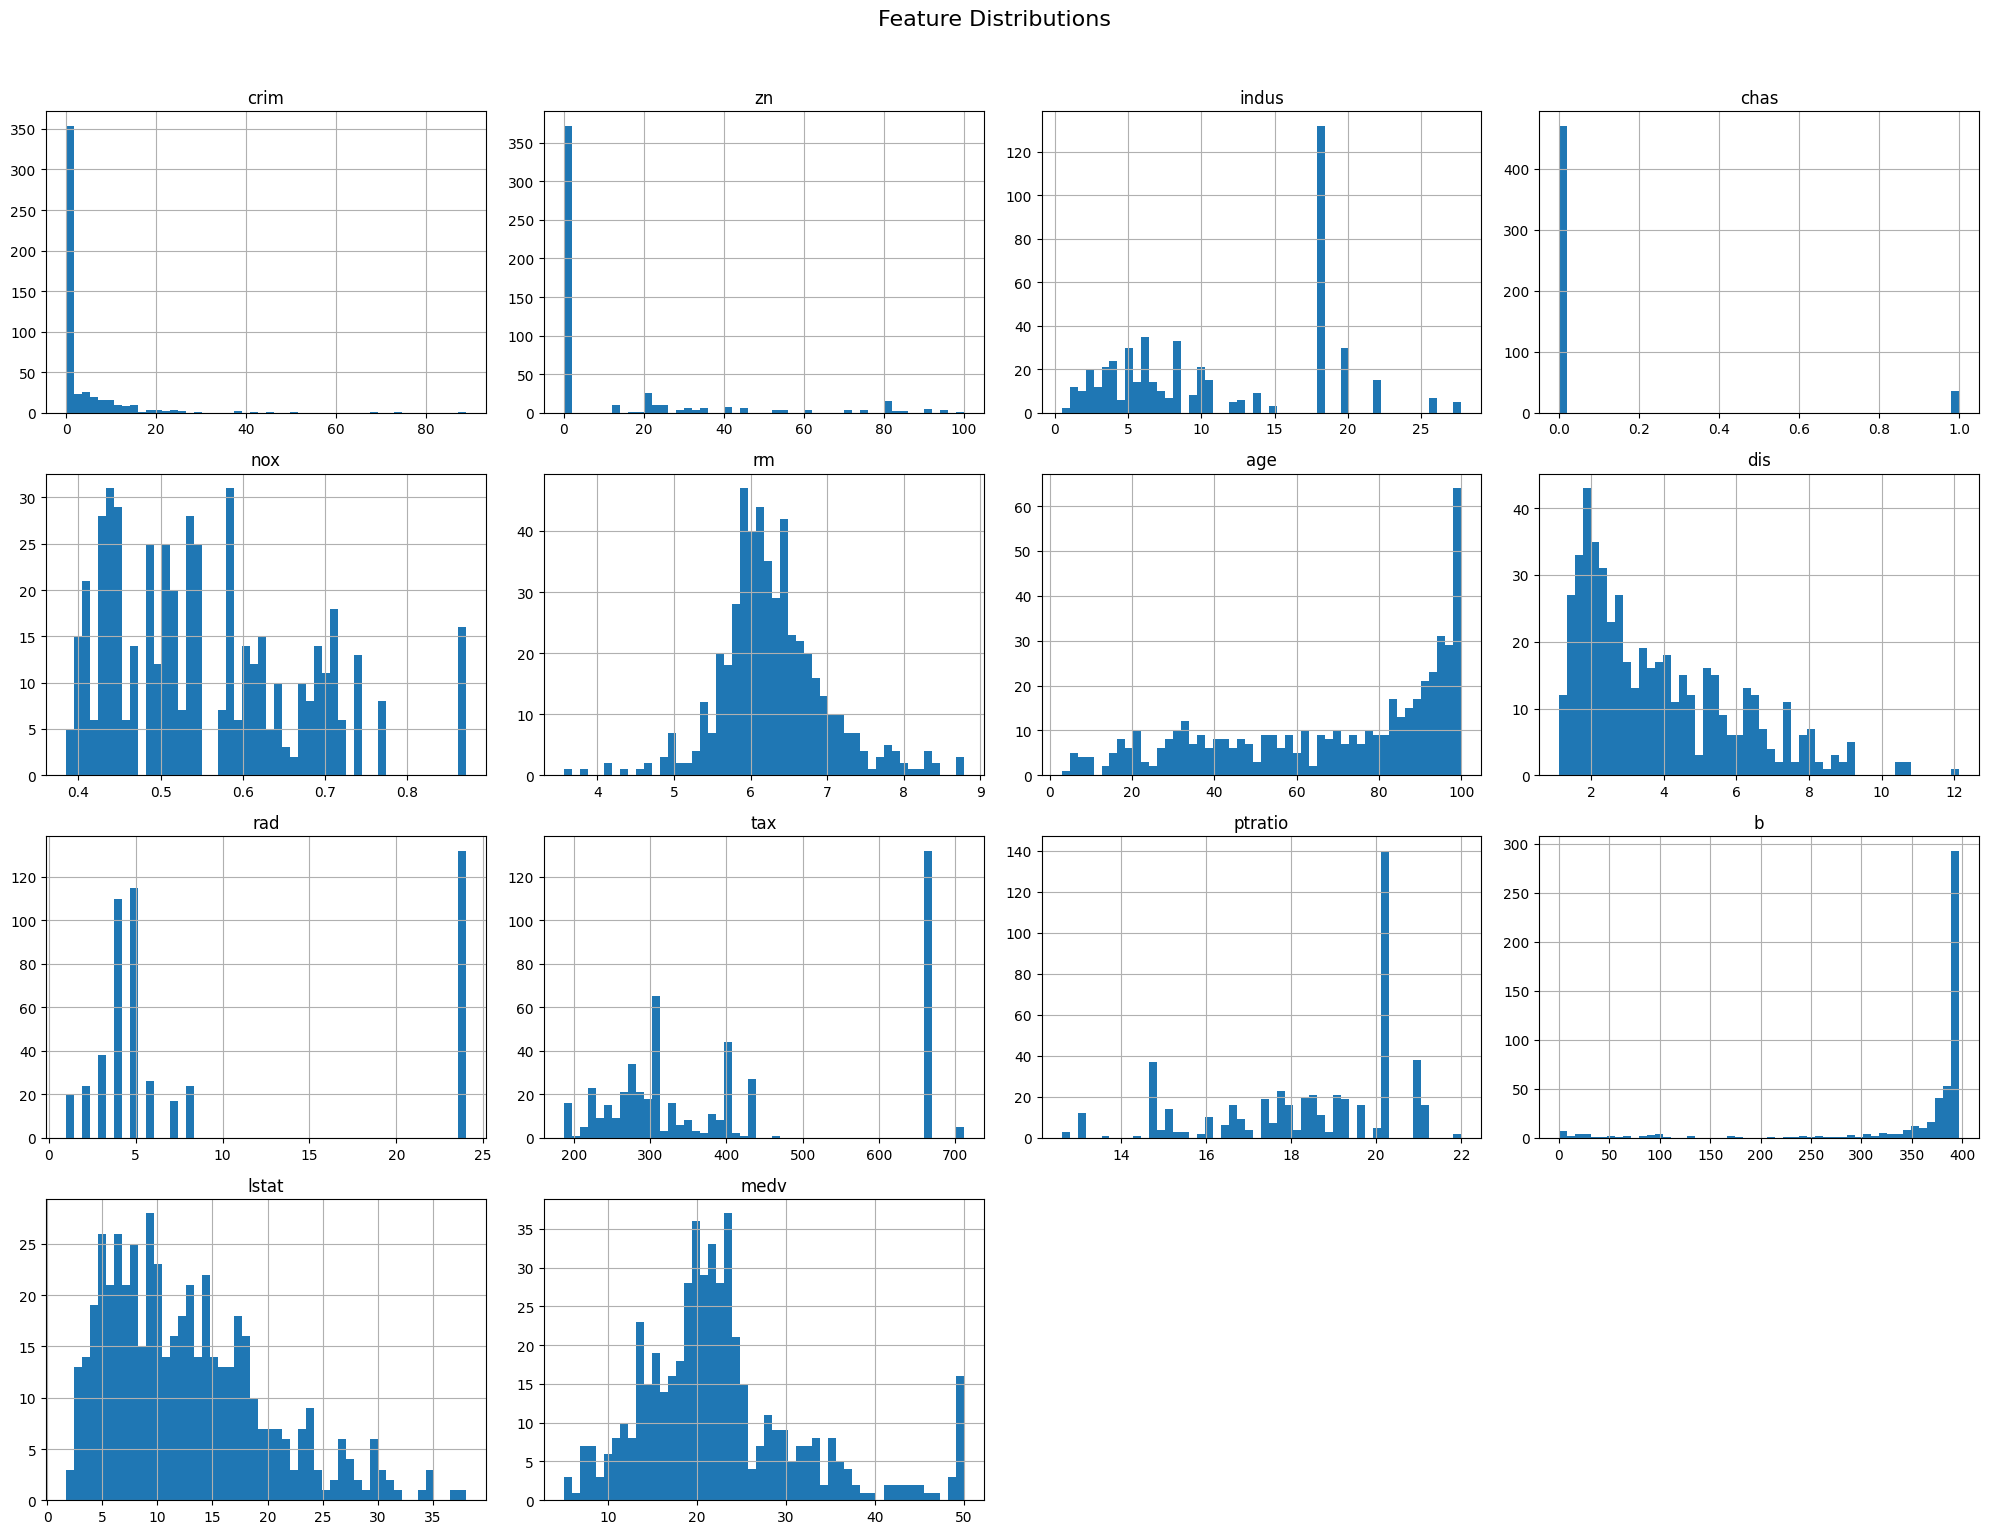

In [5]:
# Feature distributions
housing.hist(bins=50, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(housing, housing["chas"]):
    strat_train_set = housing.loc[train_idx]
    strat_test_set  = housing.loc[test_idx]

print(f"Training set : {len(strat_train_set)} rows")
print(f"Test set     : {len(strat_test_set)} rows")
print("\nClass distribution in test set:")
print(strat_test_set["chas"].value_counts())

Training set : 404 rows
Test set     : 102 rows

Class distribution in test set:
chas
0    95
1     7
Name: count, dtype: int64


In [7]:
# Work on a copy of the training set
housing = strat_train_set.copy()

# Engineered feature: tax burden per room
housing["taxrm"] = housing["tax"] / housing["rm"]

# Correlation with target
corr = housing.corr()["medv"].sort_values(ascending=False)
print("Correlation with medv (house price):")
print(corr.to_string())

Correlation with medv (house price):
medv       1.000000
rm         0.679894
b          0.361761
zn         0.339741
dis        0.240451
chas       0.205066
age       -0.364596
rad       -0.374693
crim      -0.393715
nox       -0.422873
tax       -0.456657
indus     -0.473516
ptratio   -0.493534
taxrm     -0.525160
lstat     -0.740494


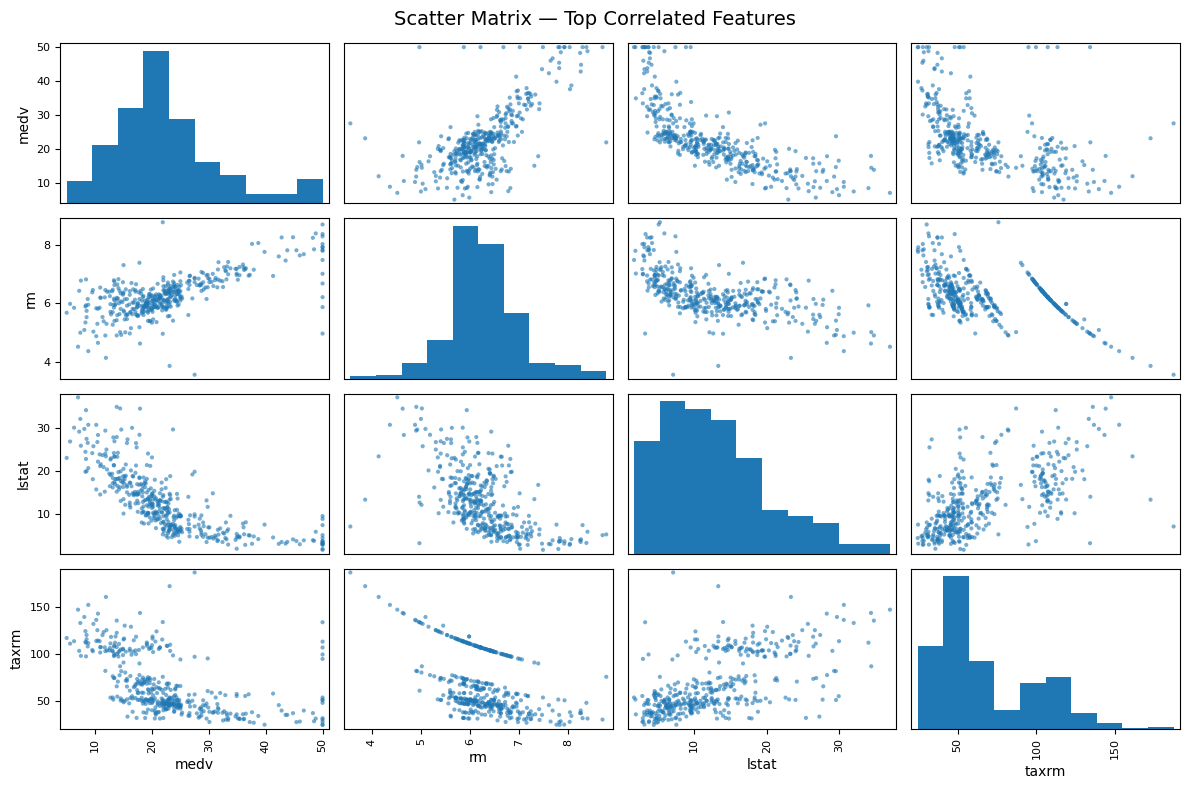

In [8]:
# Scatter matrix for top correlated features
top_features = ["medv", "rm", "lstat", "taxrm"]
scatter_matrix(housing[top_features], figsize=(12, 8), alpha=0.6)
plt.suptitle("Scatter Matrix — Top Correlated Features", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Separate features and target; drop engineered feature used only for EDA
X_train = strat_train_set.drop(columns=["medv"])
y_train = strat_train_set["medv"].copy()

In [10]:
pipeline = Pipeline([
    ("imputer",    SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler()),
])

X_train_prepared = pipeline.fit_transform(X_train)
print(f"Prepared training shape: {X_train_prepared.shape}")

Prepared training shape: (404, 13)


In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_prepared, y_train)

# Training RMSE (in-sample — expected to be low)
train_preds = model.predict(X_train_prepared)
train_rmse  = np.sqrt(mean_squared_error(y_train, train_preds))
print(f"Training RMSE: {train_rmse:.4f}")

Training RMSE: 1.3082


In [12]:
def evaluate_cv(model, X, y, cv=10):
    """Run k-fold CV and print RMSE scores, mean, and std."""
    scores = cross_val_score(
        model, X, y,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-scores)
    print(f"CV RMSE scores : {np.round(rmse_scores, 3)}")
    print(f"Mean           : {rmse_scores.mean():.4f}")
    print(f"Std deviation  : {rmse_scores.std():.4f}")
    return rmse_scores

cv_scores = evaluate_cv(model, X_train_prepared, y_train)

CV RMSE scores : [2.782 3.045 4.399 2.625 3.616 2.631 5.013 3.257 3.194 3.428]
Mean           : 3.3989
Std deviation  : 0.7355


In [13]:
X_test = strat_test_set.drop(columns=["medv"])
y_test = strat_test_set["medv"].copy()

X_test_prepared  = pipeline.transform(X_test)   # transform only — no fit!
final_predictions = model.predict(X_test_prepared)

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(f"Test RMSE: {final_rmse:.4f}")

Test RMSE: 2.9750


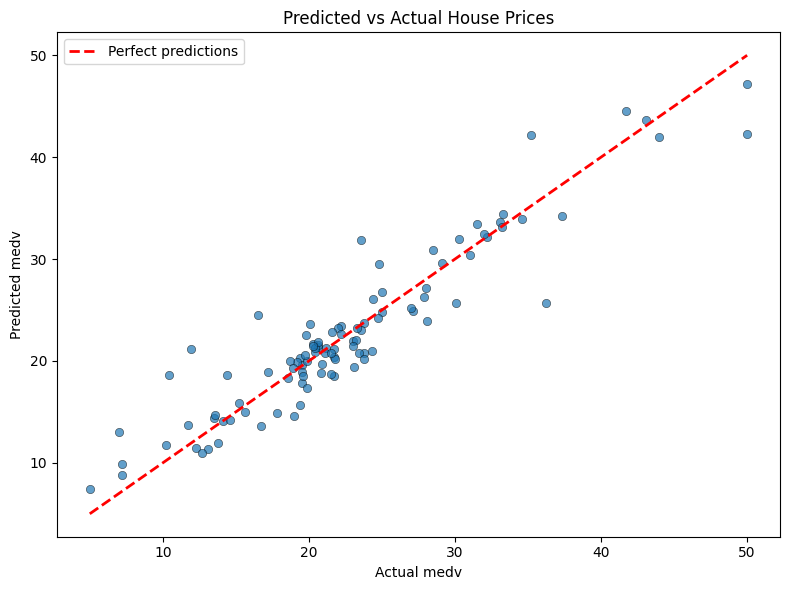

In [14]:
# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.7, edgecolors="k", linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect predictions")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
MODEL_PATH = "real_estate.joblib"
dump(model, MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

Model saved to 'real_estate.joblib'


In [16]:
# Example: load and predict on a single sample
loaded_model = load(MODEL_PATH)

sample = X_test_prepared[:1]            # first test sample (already scaled)
prediction = loaded_model.predict(sample)

print(f"Predicted medv : {prediction[0]:.2f}")
print(f"Actual medv    : {y_test.iloc[0]:.2f}")

Predicted medv : 24.52
Actual medv    : 16.50
